# K-Means / K-Medoids Clustering (Toggle)

## Blocks
1. Categorical preprocessing (one-hot)
2. Outlier detection and removal
3. Scaling and clustering
4. Silhouette and PCA visualization

## 1) Imports and Shared Helpers

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_dataset_path():
    candidates = [
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Cannot find Mushroom Dataset/mushrooms 2.csv from current location.')

def load_and_clean_data(rare_threshold=0.01):
    df = pd.read_csv(resolve_dataset_path())
    df = df.replace('?', np.nan).drop_duplicates().copy()

    for c in df.columns:
        if df[c].isna().any():
            if pd.api.types.is_numeric_dtype(df[c]):
                df[c] = df[c].fillna(df[c].mean())
            else:
                mode_val = df[c].mode(dropna=True)
                df[c] = df[c].fillna(mode_val.iloc[0] if not mode_val.empty else 'missing')

    outlier_mask = pd.Series(False, index=df.index)
    outlier_cols = []
    min_count = max(1, int(rare_threshold * len(df)))

    for c in df.columns:
        if c == 'class':
            continue
        counts = df[c].value_counts(dropna=False)
        rare_vals = counts[counts < min_count].index
        if len(rare_vals) > 0:
            is_rare = df[c].isin(rare_vals)
            outlier_mask = outlier_mask | is_rare
            outlier_cols.append(c)

    df['is_outlier'] = outlier_mask.astype(int)
    single_cols = [c for c in df.columns if c != 'is_outlier' and df[c].nunique() <= 1]
    if single_cols:
        df = df.drop(columns=single_cols)

    return df, outlier_cols

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

try:
    from sklearn_extra.cluster import KMedoids
    HAS_KMEDOIDS = True
except ModuleNotFoundError:
    HAS_KMEDOIDS = False

## 2) Clustering Pipeline

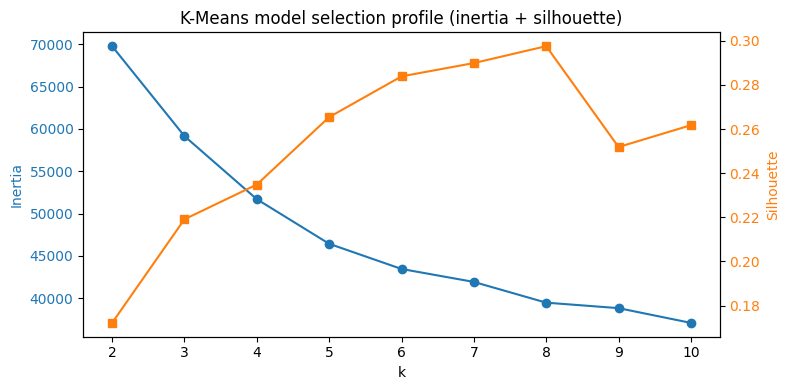

Algorithm: K-Means
Silhouette: 0.1722
ARI vs class: 0.6413
Outlier columns: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-surface-above-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color']


C:\Users\Ahmed Fahmy\AppData\Local\Temp\ipykernel_45600\889424536.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, palette='Set2')


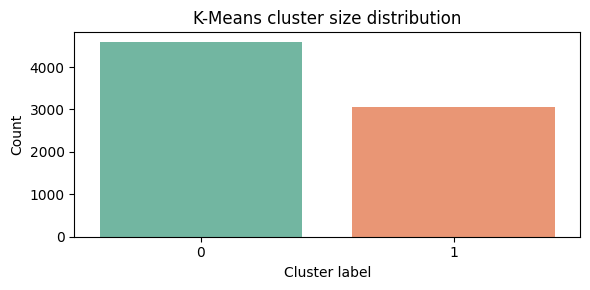

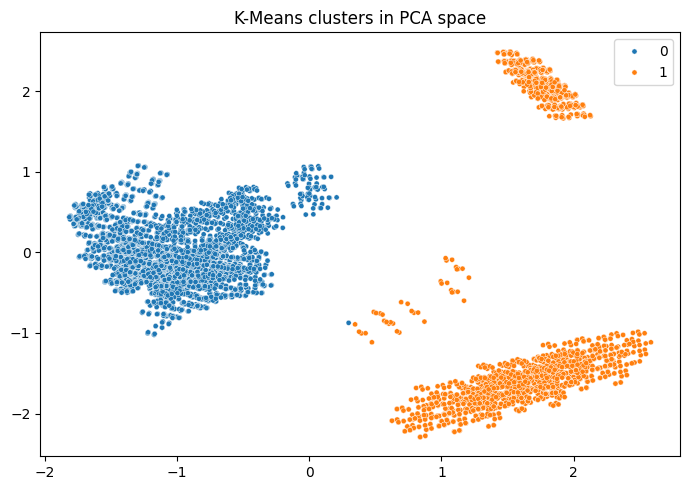

In [2]:
df_all, outlier_cols = load_and_clean_data(rare_threshold=0.01)
df = df_all[df_all['is_outlier'] == 0].drop(columns=['is_outlier']).copy()
y_true = df['class'].map({'e': 0, 'p': 1}).astype(int)
X_raw = df.drop(columns=['class'])

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X = ohe.fit_transform(X_raw)
X = MinMaxScaler().fit_transform(X)

# K-Means elbow and silhouette profile for k selection.
k_values = list(range(2, 11))
inertias = []
sil_scores = []
for k in k_values:
    km_probe = KMeans(n_clusters=k, random_state=42, n_init=10)
    probe_labels = km_probe.fit_predict(X)
    inertias.append(km_probe.inertia_)
    sil_scores.append(silhouette_score(X, probe_labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_values, inertias, marker='o', color='tab:blue')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker='s', color='tab:orange')
ax2.set_ylabel('Silhouette', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
plt.title('K-Means model selection profile (inertia + silhouette)')
plt.tight_layout()
plt.show()

# Toggle clustering algorithm:
USE_KMEDOIDS = False
## Set to True to run K-Medoids instead of K-Means.

if USE_KMEDOIDS:
    if not HAS_KMEDOIDS:
        raise ModuleNotFoundError('KMedoids requires scikit-learn-extra. Install with: pip install scikit-learn-extra')
    model = KMedoids(n_clusters=2, random_state=42, metric='manhattan')
    algo_name = 'K-Medoids'
else:
    model = KMeans(n_clusters=2, random_state=42, n_init=10)
    algo_name = 'K-Means'

labels = model.fit_predict(X)
print('Algorithm:', algo_name)
print('Silhouette:', round(silhouette_score(X, labels), 4))
print('ARI vs class:', round(adjusted_rand_score(y_true, labels), 4))

print('Outlier columns:', outlier_cols)

cluster_counts = pd.Series(labels).value_counts().sort_index()
plt.figure(figsize=(6, 3))
sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, palette='Set2')
plt.title(f'{algo_name} cluster size distribution')
plt.xlabel('Cluster label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=labels, palette='tab10', s=14)
plt.title(f'{algo_name} clusters in PCA space')
plt.tight_layout()
plt.show()